# Dimensionality Reduction in Machine Learning

**Goal:** Explore methods of dimensionality reduction in Machine Learning.

---

## Motivations
Some datasets can have thousands of features many of which are correlated or not useful. Reducing our feature space can help our model train faster and allows us to have less data loaded in saving memory. It's difficult to think in 4 dimension and thus even harder to think in 200; to get a better understanding we can reduce to 2 or 3 dimensions to visualize our data and get a better understanding.  


## Summary 
This notebook will look at popular methods of dimensionality reduction. First, we will detail popular visualization methods for high dimensional data and look at the pros and cons for each. Next, we will detail data preprocessing methods and see how they each effect the quality of our a few different models. Lastly, we will compare both our best models on the reduced data and the non-reduced data.

### Table of Contents
1. Dataset Description and Preprocessing

2. General Methodologies

3. Visualization Methods 

4. Pre-training Methods

5. Training Models with Non-Reduced Dataset

6. Training Models with Reduced Dataset

7. Conclusion

## Dataset and Preprocessing - SECOM

This dataset contains measured signals collected from sensors and or measurement points from the semi-conductor manufacturing process. Each instance contains the signals for a semi-conductor production entity and a pass/fail label, where -1 is a pass and 1 is a fail, as well as a timestamp to mark the point in the production process.

- **Instances:** 1567
- **Features:** 591 (Including label)
- **Feature Types:** Real
- **Missing data:** Marked as NaN
- **Label:** 1: Fail, -1: Pass (Timestamp of the form: DD/MM/YYYY HR:MIN:00) 




In [73]:
# IMPORTS -----
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

# SIze of set
INSTANCES = 1597
FEATURES = 590

# LOAD IN DATA ------
X = pd.read_csv("data/secom.data", sep=r"\s+", header=None)
y = pd.read_csv("data/secom_labels.data", sep=r"\s+", header=None)

assert X.shape == (1567, 590), "secom.data loaded improperly"
assert y[0].shape == (1567,), "secom_labels.dta loaded improperly"

# make into one df -----
df = X.copy()
df["target"] = y[0]
df.shape

assert df.shape == (1567, 591), "df has improper dimensions"

# count features NaNs ------
nan_per_feature = df.isna().sum() / INSTANCES
nan_sorted      = nan_per_feature[nan_per_feature > 0].sort_values(ascending=False)

print(f"Missing labels: {df["target"].isna().sum()}")
print(f'''Number of features missing more than 30% of entries: {
    sum(i > 0.3 for i in nan_per_feature)
}''')


# drop feature missing 30% of entries or more -----
df = df.loc[:, df.isna().mean() < 0.3]

# new df shape ------
print(f"New data frame shape: {df.shape}") 


Missing labels: 0
Number of features missing more than 30% of entries: 32
New data frame shape: (1567, 559)


## Pipeline
Simple pipeline for scaling and imputation.

In [74]:
# our pipeline -----
pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
])

# new X and y -----
X = df.drop(columns=["target"])
y = df["target"]

X = pipeline.fit_transform(X)

# sanity check -----
assert X.shape == (1567, 558), "data not the correct size"
assert y.shape == (1567,), "labels not the correct size"

## General Methodologies

There are 2 main approaches for dimensionality reduction. One is projection based methods which as the name implies reduces dimension by projecting the data, this is best used on linear data. The other are manifold based methods, which can best be thought of as learning method that attempts to generalize projections methods to work well for non linear data.


### Projection Methods
We will look at Principle Component Analysis (PCA), as well as Randomized Projection methods.


### Manifold

We will look at and detail Isomap, Local Linear Embedding (LLE), t-SNE, and DBSCAN.

## Dimensional Reductionality Methods
All dimensionality reduction methods can be used for data visualization, given that they can produce 2 or 3 dimensional data. First, lets explore all our methods and compare each of there visualizations. Next, lets talk about which ones should and shouldn't be used to train models and why.


### Visualizations

---


### Principle Component Analysis (PCA)

In PCA the data is linearly transformed onto a new coordinate system where the new axis are the ones that capture the most variance. The first principle component is the direction that captures the most variance. The next principle component is the a direction orthognal that explains the most of the variance left, and so on.


In most visualiation applications we will only look at the first 2 or 3 principle components and then check the variance captured to see how well the visualization represents our data.

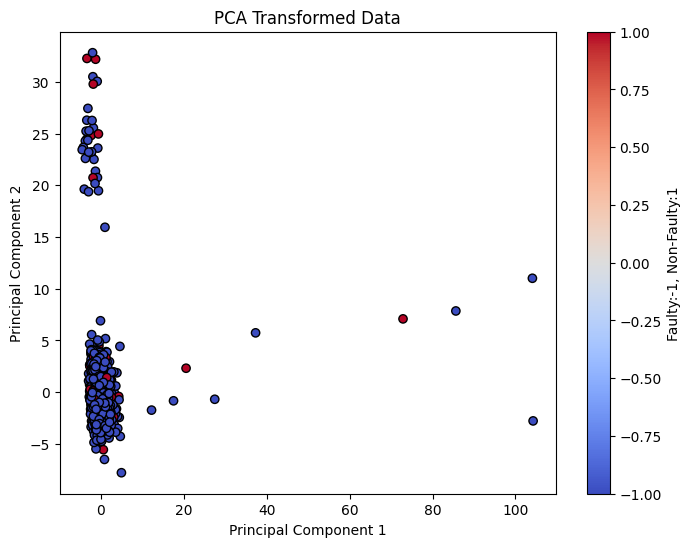

[25.5618812 17.1008243]


In [75]:
# PCA -----
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(X)

x_pca, y_pca = zip(*pca_transformed)

plt.figure(figsize=(8,6))
plt.scatter(x_pca, y_pca, c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Faulty:-1, Non-Faulty:1")
plt.show()

print(f"{pca.explained_variance_}")


In [ ]:
# our explained variance -----
print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Cumulative explained varince: {np.cumsum(pca.explained_variance_ratio_)}")


Explained variance: [0.0577954  0.03866495]
Cumulative explained varince: [0.0577954  0.09646035]


Here 2 principle components only explain about ~10% of the variance of our dataset. Not good. It's clear that our visualization is poor, or the data is poor as we should have 2 seperable clusters of blue and red in the case of either label. Let's move on to a manifold leaning method.

---

### Local Linear Embedding (LLE) 

Here I will explain the method LLE uses to reduce dimensions. 

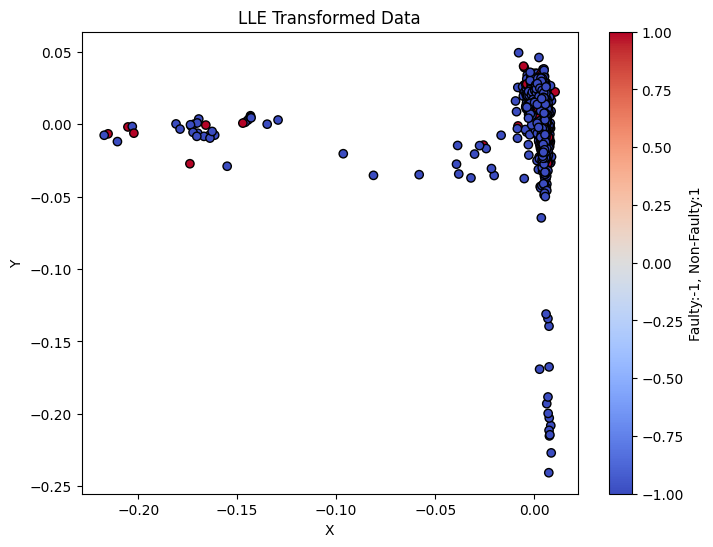

In [88]:
# LLE
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=65)
lle_transformed = lle.fit_transform(X)

x_lle, y_lle = zip(*lle_transformed)

plt.figure(figsize=(8,6))
plt.scatter(x_lle, y_lle, c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("LLE Transformed Data")
plt.colorbar(label="Faulty:-1, Non-Faulty:1")
plt.show()

c:\Users\grant\dimensionality\.venv\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\grant\dimensionality\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\grant\dimensionality\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\grant\dimensionality\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXin

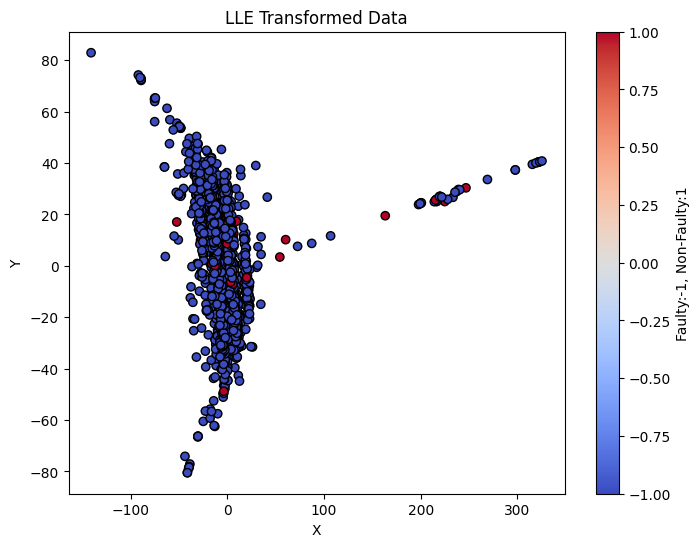

In [89]:
# ISOmap
lle = Isomap(n_components=2)
lle_transformed = lle.fit_transform(X)

x_lle, y_lle = zip(*lle_transformed)

plt.figure(figsize=(8,6))
plt.scatter(x_lle, y_lle, c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("LLE Transformed Data")
plt.colorbar(label="Faulty:-1, Non-Faulty:1")
plt.show()

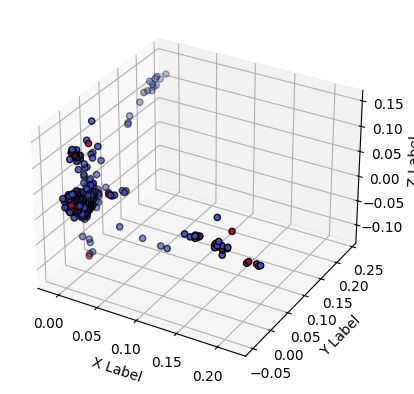

In [93]:
# LLE
lle = LocallyLinearEmbedding(n_components=3, n_neighbors=65)
lle_transformed = lle.fit_transform(X)

x_lle, y_lle, z_lle = zip(*lle_transformed)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(x_lle, y_lle, z_lle, c =y, cmap='coolwarm', edgecolor='k')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()



### Training

---

## Training Models with Non-Reduced Datasets

## Traingin Models with Reduced Datasets